# Klasyfikacja obrazów - wprowadzenie

W ramach laboratorium przyjrzymy się zagadnieniu klasyfikacji obrazów za pomocą klasyfikatora SVM operującego na:

1.   pikselach
2.   cechach wydzielonych z obrazu.

Za testowy zbiór posłuży nam klasyczny zestaw danych do klasyfikacji CIFAR-10 [1]. Ćwiczenie oparte jest o kod z [2], z tą różnicą, że nie będziemy pisać własnych klasyfikatorów, ale użyjemy pakietu scikit-learn [3].


## 1. Klasyfikacja obrazów jako wektorów pikseli

### Kod przygotowujący (wykonaj)


In [ ]:
# potrzebne pakiety
import random
import numpy as np
import matplotlib.pyplot as plt
import os
from imageio import imread
import pickle
import platform

# funkcje do wczytania danych
def load_CIFAR10(ROOT):
    """ load all of cifar """
    xs = []
    ys = []
    for b in range(1, 6):
        f = os.path.join(ROOT, "data_batch_%d" % (b,))
        X, Y = load_CIFAR_batch(f)
        xs.append(X)
        ys.append(Y)
    Xtr = np.concatenate(xs)
    Ytr = np.concatenate(ys)
    del X, Y
    Xte, Yte = load_CIFAR_batch(os.path.join(ROOT, "test_batch"))
    return Xtr, Ytr, Xte, Yte

def load_pickle(f):
    version = platform.python_version_tuple()
    if version[0] == "2":
        return pickle.load(f)
    elif version[0] == "3":
        return pickle.load(f, encoding="latin1")
    raise ValueError("invalid python version: {}".format(version))


def load_CIFAR_batch(filename):
    """ load single batch of cifar """
    with open(filename, "rb") as f:
        datadict = load_pickle(f)
        X = datadict["data"]
        Y = datadict["labels"]
        X = X.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1).astype("float")
        Y = np.array(Y)
        return X, Y

# Parametry wykresów:
%matplotlib inline
plt.rcParams['figure.figsize'] = (12.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

In [ ]:
!wget https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
!mkdir cifar-10
!tar -xvf  'cifar-10-python.tar.gz' -C 'cifar-10'


--2025-11-25 08:13:25--  https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz
Resolving www.cs.toronto.edu (www.cs.toronto.edu)... 128.100.3.30
Connecting to www.cs.toronto.edu (www.cs.toronto.edu)|128.100.3.30|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 170498071 (163M) [application/x-gzip]
Saving to: ‘cifar-10-python.tar.gz’

cifar-10-python.tar 100%[===================>] 162.60M  22.0MB/s    in 7.0s    

2025-11-25 08:13:32 (23.3 MB/s) - ‘cifar-10-python.tar.gz’ saved [170498071/170498071]

mkdir: cannot create directory ‘cifar-10’: File exists
cifar-10-batches-py/
cifar-10-batches-py/data_batch_4
cifar-10-batches-py/readme.html
cifar-10-batches-py/test_batch
cifar-10-batches-py/data_batch_3
cifar-10-batches-py/batches.meta
cifar-10-batches-py/data_batch_2
cifar-10-batches-py/data_batch_5
cifar-10-batches-py/data_batch_1


### Wczytanie danych

In [ ]:
# Wczytaj dane:
cifar10_dir = 'cifar-10/cifar-10-batches-py'

# jeśli dane były wczytane wcześniej, usuń zmienne:
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# Wypisz rozmiar wczytanych danych
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Training data shape:  (50000, 32, 32, 3)
Training labels shape:  (50000,)
Test data shape:  (10000, 32, 32, 3)
Test labels shape:  (10000,)


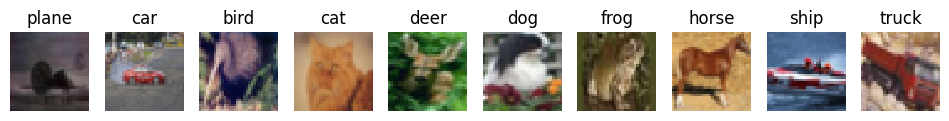

In [ ]:
# Wyświetlamy po 1 przykładowym obrazku ze zbioru uczącego:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
num_classes = len(classes)
for y, cls in enumerate(classes):
    idxs = np.flatnonzero(y_train == y)
    idx = np.random.choice(idxs, 1, replace=False)[0]
    plt.subplot(1, num_classes, y + 1)
    plt.imshow(X_train[idx].astype('uint8'))
    plt.axis('off')
    plt.title(cls)
plt.show()

In [ ]:
# Podział danych na podzbiory: trenujący i testowy; tworzymy także niewielki zbiór
# o nazwie dev który posłuży nam do testowania kodu przed faktycznym uczeniem
# (czy klasy przyjmują utworzone dane, czy nie ma błędów itd.)
num_training = 49000
num_test = 1000
num_dev = 500

# Nasz zbiór uczący to num_training próbek wybranych z oryginalnego zbioru uczącego
mask = range(num_training)
X_train = X_train[mask]
y_train = y_train[mask]

# Zbiór dev jest niewielkim, losowo wybranym podzbiorem zbioru uczącego
mask = np.random.choice(num_training, num_dev, replace=False)
X_dev = X_train[mask]
y_dev = y_train[mask]

# Nasz zbiór testujący to num_test próbek wybranych z oryginalnego zbioru testowego
mask = range(num_test)
X_test = X_test[mask]
y_test = y_test[mask]

print('Train data shape: ', X_train.shape)
print('Train labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

Train data shape:  (49000, 32, 32, 3)
Train labels shape:  (49000,)
Test data shape:  (1000, 32, 32, 3)
Test labels shape:  (1000,)


### Preprocessing (uzupełnij kod w miejscu komentarzy z etykietą TODO)

Tutaj jest moment na preprocessing danych: po pierwsze potrzebujemy reprezentacji danych w postaci wektorów o rozmiarze 3072x1 a nie obrazów 32x32x3. Dzięki takiemu zabiegowi, będziemy mieć macierze danych uczących i trenujących, w których każdy wiersz jest jedną próbką danych (jednym obrazem). Użyj funkcji reshape do transformacji danych. Przykładowo dotychczasowy testowy zbiór mający rozmiar: (1000, 32, 32, 3) powinien mieć 2 wymiary: (1000, 3072)

In [ ]:
# TODO: tutaj wykonaj reshaping
X_train =
X_test =
X_dev =

# Wypisz rozmiary danych:
print('Training data shape: ', X_train.shape)
print('Test data shape: ', X_test.shape)
print('dev data shape: ', X_dev.shape)

In [ ]:
# TODO: oblicz uśredniony obraz
mean_image =
print(mean_image.shape)
# wyswietl uśredniony obraz:
plt.figure(figsize=(4,4))
plt.imshow(mean_image.reshape((32,32,3)).astype('uint8')) # visualize the mean image
plt.show()

# TODO: odejmij uśredniony obraz od wszystkich zbiorów (trenujący, testowy, dev)
X_train =
X_test =
X_dev =

# tzw. bias trick, nie zmieniamy
X_train = np.hstack([X_train, np.ones((X_train.shape[0], 1))])
X_test = np.hstack([X_test, np.ones((X_test.shape[0], 1))])
X_dev = np.hstack([X_dev, np.ones((X_dev.shape[0], 1))])

print(X_train.shape, X_test.shape, X_dev.shape)

## SVM na pikselach obrazów

Poniższy kod uczy klasyfikator SVM na zbiorze trenującym -> w wektorach poszczególnych obrazów nie ma wydzielonych cech, tylko surowe piksele (po odjęciu obrazu uśrednionego i reshapingu, ale wciąż operujemy na niskopoziomowych wartościach intensywności).

In [ ]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report

# Tworzymy klasyfikator SVM z optymalizatorem stochastic gradient descent
# TODO: Zastosuj SGDClassifier z scikit-learn
SGDC =

# UWAGA: najpierw wykonaj uczenie na zbiorze dev i sprawdź czy wszystko działa!
SGDC.fit(X_train, y_train)

In [ ]:
# ewaluacja na zbiorze testowym
y_test_SGDC_model = SGDC.predict(X_test)
print("SGDC Accuracy :", accuracy_score(y_test, y_test_SGDC_model))

In [ ]:
from sklearn.metrics import plot_confusion_matrix

# wyrysujemy macierz pomyłek
plot_confusion_matrix(SGDC, X_test, y_test)
plt.show()

## Zadanie: Przeprowadź klasyfikację na tych samych danych klasyfikatorem k-NN i porównaj wyniki

In [ ]:
# TODO: k-nn

## Cechy obrazów na przykładzie HOG (Histogram of oriented gradients)

 #### *UWAGA: potrzebujesz pliku features.py* - wgraj go korzystając z menu po lewej (Files -> ikonka upload)

---



In [ ]:
from features import *

# jeśli dane były wczytane wcześniej, usuń zmienne:
try:
   del X_train, y_train
   del X_test, y_test
   print('Clear previously loaded data.')
except:
   pass

X_train, y_train, X_test, y_test = load_CIFAR10(cifar10_dir)

# Wypisz rozmiar wczytanych danych
print('Training data shape: ', X_train.shape)
print('Training labels shape: ', y_train.shape)
print('Test data shape: ', X_test.shape)
print('Test labels shape: ', y_test.shape)

num_color_bins = 10 # Number of bins in the color histogram
feature_fns = [hog_feature, lambda img: color_histogram_hsv(img, nbin=num_color_bins)]
X_train_feats = extract_features(X_train, feature_fns, verbose=True)
X_test_feats = extract_features(X_test, feature_fns)

# Preprocessing: Subtract the mean feature
mean_feat = np.mean(X_train_feats, axis=0, keepdims=True)
X_train_feats -= mean_feat
X_test_feats -= mean_feat

# Preprocessing: Divide by standard deviation. This ensures that each feature
# has roughly the same scale.
std_feat = np.std(X_train_feats, axis=0, keepdims=True)
X_train_feats /= std_feat
X_test_feats /= std_feat

# Preprocessing: Add a bias dimension
X_train_feats = np.hstack([X_train_feats, np.ones((X_train_feats.shape[0], 1))])
X_test_feats = np.hstack([X_test_feats, np.ones((X_test_feats.shape[0], 1))])

### Uczenie SVM na cechach obrazów

In [ ]:
# Tworzymy klasyfikator SVM z optymalizatorem stochastic gradient descent
SGDC_on_HOG = SGDClassifier(max_iter=1500, tol=1e-3, learning_rate= 'constant', eta0=1e-7)

# UWAGA: najpierw wykonaj uczenie na zbiorze dev i sprawdź czy wszystko działa!
SGDC_on_HOG.fit(X_train_feats, y_train)

In [ ]:
# ewaluacja na zbiorze testowym
y_test_SGDC_on_HOG_model = SGDC_on_HOG.predict(X_test_feats)
print("SGDC_on_HOG Accuracy :", accuracy_score(y_test, y_test_SGDC_on_HOG_model))

In [ ]:
plot_confusion_matrix(SGDC_on_HOG, X_test_feats, y_test)
plt.show()

## Zadanie: Przeprowadź klasyfikację na cechach HOG klasyfikatorem k-NN i porównaj wyniki

In [ ]:
# TODO: k-NN on HOG

## Zadanie: Naucz MLP na cechach obrazów. Porównaj wyniki (accuracy) z dotychczasowymi metodami.

In [ ]:
#TODO: MLP. Skorzystaj z pakietu scikit-learn

### Literatura

1. https://www.cs.toronto.edu/~kriz/cifar.html
2. https://cs231n.github.io/
3. https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html